Package Installations before running code

In [1]:
import sys
print(sys.version)

3.13.1 (tags/v3.13.1:0671451, Dec  3 2024, 19:06:28) [MSC v.1942 64 bit (AMD64)]


In [3]:
pip install openai

  Using cached openai-1.58.1-py3-none-any.whl.metadata (27 kB)
  Using cached anyio-4.7.0-py3-none-any.whl.metadata (4.7 kB)
  Using cached distro-1.9.0-py3-none-any.whl.metadata (6.8 kB)
  Using cached httpx-0.28.1-py3-none-any.whl.metadata (7.1 kB)
  Using cached jiter-0.8.2-cp313-cp313-win_amd64.whl.metadata (5.3 kB)
  Using cached pydantic-2.10.4-py3-none-any.whl.metadata (29 kB)
  Using cached sniffio-1.3.1-py3-none-any.whl.metadata (3.9 kB)
  Using cached tqdm-4.67.1-py3-none-any.whl.metadata (57 kB)
  Using cached typing_extensions-4.12.2-py3-none-any.whl.metadata (3.0 kB)
  Using cached idna-3.10-py3-none-any.whl.metadata (10 kB)
  Using cached certifi-2024.12.14-py3-none-any.whl.metadata (2.3 kB)
  Using cached httpcore-1.0.7-py3-none-any.whl.metadata (21 kB)
  Using cached h11-0.14.0-py3-none-any.whl.metadata (8.2 kB)
  Using cached annotated_types-0.7.0-py3-none-any.whl.metadata (15 kB)
  Using cached pydantic_core-2.27.2-cp313-cp313-win_amd64.whl.metadata (6.7 kB)
Using cac

  Consider adding this directory to PATH or, if you prefer to suppress this warning, use --no-warn-script-location.
  Consider adding this directory to PATH or, if you prefer to suppress this warning, use --no-warn-script-location.
  Consider adding this directory to PATH or, if you prefer to suppress this warning, use --no-warn-script-location.
  Consider adding this directory to PATH or, if you prefer to suppress this warning, use --no-warn-script-location.


In [2]:
pip install numpy

   ---------------------------------------- 0.0/12.6 MB ? eta -:--:--
   ----------------------------- ---------- 9.4/12.6 MB 49.6 MB/s eta 0:00:01
   ---------------------------------------- 12.6/12.6 MB 39.7 MB/s eta 0:00:00
Note: you may need to restart the kernel to use updated packages.


  Consider adding this directory to PATH or, if you prefer to suppress this warning, use --no-warn-script-location.


In [4]:
pip install pandas

   ---------------------------------------- 0.0/11.5 MB ? eta -:--:--
   ---------------------------------------  11.3/11.5 MB 65.5 MB/s eta 0:00:01
   ---------------------------------------- 11.5/11.5 MB 41.8 MB/s eta 0:00:00
Note: you may need to restart the kernel to use updated packages.


In [6]:
pip install -U matplotlib

   ---------------------------------------- 0.0/8.0 MB ? eta -:--:--
   ---------------------------------------- 8.0/8.0 MB 43.3 MB/s eta 0:00:00
   ---------------------------------------- 0.0/2.2 MB ? eta -:--:--
   ---------------------------------------- 2.2/2.2 MB 48.0 MB/s eta 0:00:00
   ---------------------------------------- 0.0/2.6 MB ? eta -:--:--
   ---------------------------------------- 2.6/2.6 MB 46.7 MB/s eta 0:00:00
Note: you may need to restart the kernel to use updated packages.


  Consider adding this directory to PATH or, if you prefer to suppress this warning, use --no-warn-script-location.


In [4]:
pip show openai

Name: openaiNote: you may need to restart the kernel to use updated packages.

Version: 1.58.1
Summary: The official Python library for the openai API
Home-page: https://github.com/openai/openai-python
Author: 
Author-email: OpenAI <support@openai.com>
License: 
Location: c:\Users\Sidney\AppData\Local\Programs\Python\Python313\Lib\site-packages
Requires: anyio, distro, httpx, jiter, pydantic, sniffio, tqdm, typing-extensions
Required-by: 


Code

In [1]:
import openai
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import sys
import re
import time
from openai import OpenAI
import json
import pickle
import pandas as pd
import os

sys.path += ['../src/']
# Set a global seed for reproducibility 
# GLOBAL_SEED = 42
# np.random.seed(GLOBAL_SEED)
# random.seed(GLOBAL_SEED)

#from model import *
import model as mod
from utils import *

In [4]:
path_exp = '../results/experiments/'

print(f"Current working directory: {os.getcwd()}")
print(f"Path to experiment files: {path_exp}")
print(os.path.abspath("../results/experiments"))

Current working directory: c:\Users\Sidney\OneDrive\文件\FYP\FYP\gpt_agents-master\notebooks
Path to experiment files: ../results/experiments/
c:\Users\Sidney\OneDrive\文件\FYP\FYP\gpt_agents-master\results\experiments


In [3]:
openai.__version__

'1.58.1'

In [7]:
np.random.randint(100, size = 3)

array([98, 32, 29], dtype=int32)

In [5]:
# set simulation parameters
seed = 29
np.random.seed(seed)
# seed is disabled for testing purposes
#seed = None
noise_mean = 0
noise_sd = 1/4
temperature = 1
memory = 3
instruction_type = 'original_30-50w'
n_agents = 5
n_steps = 50
#n_steps = 5
gpt_model="gpt-3.5-turbo-0125"
#gpt_model="gpt-3.5-turbo-1106"

# Positive feedback

In [13]:
# at the moment we have to change exp num manually
expmnt_num = 3
feedback='pos'
expmnt_num = check_existing_file(path_exp, expmnt_num, feedback, instruction_type, temperature, memory, n_steps, n_agents, gpt_model)

Checking files in absolute path: c:\Users\Sidney\OneDrive\文件\FYP\FYP\gpt_agents-master\results\experiments
Looking for file: c:\Users\Sidney\OneDrive\文件\FYP\FYP\gpt_agents-master\results\experiments\expmnt_results_pos_original_30-50w_num_3_temp_1_memory_3_ntime_50_nagents_5_model_gpt-3-5-turbo-0125.csv
File expmnt_results_pos_original_30-50w_num_3_temp_1_memory_3_ntime_50_nagents_5_model_gpt-3-5-turbo-0125.csv does not exist. Safe to proceed with experiment number 3.


In [14]:
#op =original positive
p_array_op, pe_agents_time_op, rewards_agents_time_op, messages_list_op  = mod.run_experiment(seed,\
                expmnt_num, noise_mean, noise_sd, temperature, memory=memory, gpt_model=gpt_model, n_steps=n_steps, n_agents=n_agents,
                feedback=feedback, instruction_type=instruction_type, prints_on=True,\
                save_res_bool=True, path_exp=path_exp)

Experiment Fingerprints: b6d4122e8155c6a66e45d4f074371de4
 
 Time: 0, agent: 0 

{'role': 'user', 'content': 'This is the first time step, give an initial price prediction'}
{'role': 'assistant', 'content': '{\n"reasoning": "I will start with a neutral prediction, assuming that demand and supply are balanced in the first period. I expect the price to be around the middle range of potential prices (around 50 euros)",\n"predictedValue": 50\n}'}
 
 Time: 0, agent: 1 

{'role': 'user', 'content': 'This is the first time step, give an initial price prediction'}
{'role': 'assistant', 'content': '{\n  "reasoning": "I will start with an initial prediction based on the average price from the historical data available.",\n  "predictedValue": 50.00\n}'}
 
 Time: 0, agent: 2 

{'role': 'user', 'content': 'This is the first time step, give an initial price prediction'}
{'role': 'assistant', 'content': '{\n  "reasoning": "As this is the first time step, I assume a moderate price point to kickstart t

In [15]:
feedback='pos'
for i in range(1, 11):
    expmnt_num = check_existing_file(path_exp, i, feedback, instruction_type, temperature, memory, n_steps, n_agents, gpt_model)
    p_array_op, pe_agents_time_op, rewards_agents_time_op, messages_list_op  = mod.run_experiment(seed,\
                expmnt_num, noise_mean, noise_sd, temperature, memory=memory, gpt_model=gpt_model, n_steps=n_steps, n_agents=n_agents,
                feedback=feedback, instruction_type=instruction_type, prints_on=True,\
                save_res_bool=True, path_exp=path_exp)

Checking files in absolute path: c:\Users\Sidney\OneDrive\文件\FYP\FYP\gpt_agents-master\results\experiments
Looking for file: c:\Users\Sidney\OneDrive\文件\FYP\FYP\gpt_agents-master\results\experiments\expmnt_results_pos_original_30-50w_num_1_temp_1_memory_3_ntime_50_nagents_5_model_gpt-3-5-turbo-0125.csv
File expmnt_results_pos_original_30-50w_num_1_temp_1_memory_3_ntime_50_nagents_5_model_gpt-3-5-turbo-0125.csv does not exist. Safe to proceed with experiment number 1.
Experiment Fingerprints: 85951bd6497ca79b2017f02728f30e6f
 
 Time: 0, agent: 0 

{'role': 'user', 'content': 'This is the first time step, give an initial price prediction'}
{'role': 'assistant', 'content': '{\n    "reasoning": "As this is the first time step, I will use a neutral approach and assume a price close to the mid-range of the possible price spectrum (0-100 euros).",\n    "predictedValue": 50.00\n}'}
 
 Time: 0, agent: 1 

{'role': 'user', 'content': 'This is the first time step, give an initial price prediction

In [11]:
pe_agents_time_op.shape

(5, 50)

Text(0.5, 0, 'Time step')

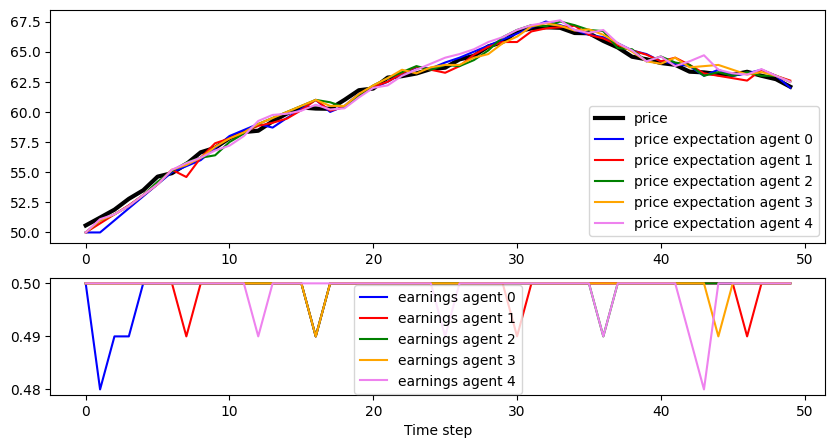

In [12]:
fig, axes = plt.subplots(nrows=2, ncols=1, figsize=(10, 5), gridspec_kw={'height_ratios': [2, 1]})
colors = ["blue","red","green","orange","violet","cyan","gold"]

axes[0].plot(p_array_op,label="price",color="black",linewidth = 3)
for i in range(n_agents):
    axes[0].plot(pe_agents_time_op[i,:],label="price expectation agent "+str(i),color=colors[i])
    axes[1].plot(rewards_agents_time_op[i,:],label="earnings agent "+str(i),color=colors[i])

#axes[0].set_ylim(0,100)
axes[0].legend()
axes[1].legend()

axes[1].set_xlabel("Time step")
# axes[0].set_xticks(range(n_steps))
# axes[1].set_xticks(range(n_steps))

Seed = 0 
First fingerprint = 17ea0e8cd5950b3ad6a70158552235d5
Second fingerprint = 17ea0e8cd5950b3ad6a70158552235d5

In [10]:
# df = pd.read_csv("../results/experiments/expmnt_results_pos_original_30-50w_num_1_temp_1_ntime_50_nagents_5.csv")
df = pd.read_csv("../results/experiments/expmnt_results_pos_original_30-50w_num_0_temp_1_memory_3_ntime_5_nagents_5_model_gpt-3-5-turbo-1106.csv")

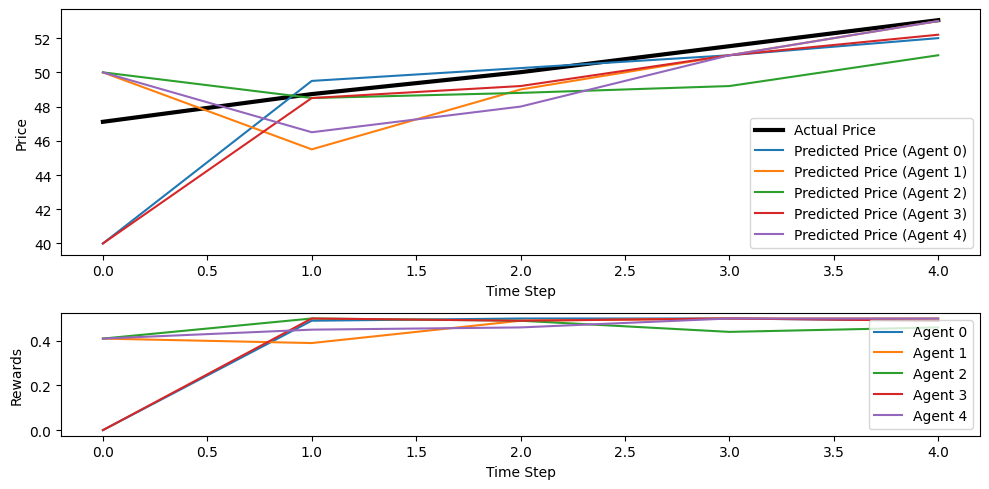

In [11]:
# Create figure and subplots
fig, axs = plt.subplots(nrows=2, ncols=1, figsize=(10, 5), gridspec_kw={'height_ratios': [2, 1]})

# Plot actual and predicted prices over time_step
axs[0].plot(df['time_step'], df['actual_price'], label='Actual Price', color="black",linewidth = 3)
for agent_id, group in df.groupby('agent_id'):
    axs[0].plot(group['time_step'], group['predicted_price'], label=f'Predicted Price (Agent {agent_id})')
axs[0].set_xlabel('Time Step')
axs[0].set_ylabel('Price')
axs[0].legend()

# Plot rewards by agent_id over time_step
for agent_id, group in df.groupby('agent_id'):
    axs[1].plot(group['time_step'], group['rewards'], label=f'Agent {agent_id}')
axs[1].set_xlabel('Time Step')
axs[1].set_ylabel('Rewards')
axs[1].legend()

plt.tight_layout()
plt.show()

# Negative feedback

In [10]:
expmnt_num = 1
feedback='neg'
expmnt_num = check_existing_file(path_exp, expmnt_num, feedback, instruction_type, temperature, memory, n_steps, n_agents, gpt_model)

File expmnt_results_neg_original_30-50w_num_1_temp_1_memory_3_ntime_50_nagents_5_model_gpt-3-5-turbo-0125.csv does not exist. Safe to proceed.


In [11]:
#on =original negative
p_array_on, pe_agents_time_on, rewards_agents_time_on, messages_list_on  = mod.run_experiment(seed,\
                expmnt_num, noise_mean, noise_sd, temperature, memory=memory, gpt_model=gpt_model, n_steps=n_steps, n_agents=n_agents,
                feedback=feedback, instruction_type=instruction_type, prints_on=True,\
                save_res_bool=True, path_exp=path_exp)

 
 Time: 0, agent: 0 

{'role': 'user', 'content': 'This is the first time step, give an initial price prediction'}
{'role': 'assistant', 'content': '{\n  "reasoning": "I will start with a moderate initial prediction based on the historical data available for the product. I will consider the past trends and the general market condition for my initial estimate.",\n  "predictedValue": 50.00\n}'}
 
 Time: 0, agent: 1 

{'role': 'user', 'content': 'This is the first time step, give an initial price prediction'}
{'role': 'assistant', 'content': '{\n  "reasoning": "I will start with a moderate price prediction to assess the market response. I will consider typical demand and supply factors for this product.",\n  "predictedValue": 50.00\n}'}
 
 Time: 0, agent: 2 

{'role': 'user', 'content': 'This is the first time step, give an initial price prediction'}
{'role': 'assistant', 'content': '{\n  "reasoning": "As this is the very first period, we don\'t have historical prices to base our predict

Text(0.5, 0, 'Time step')

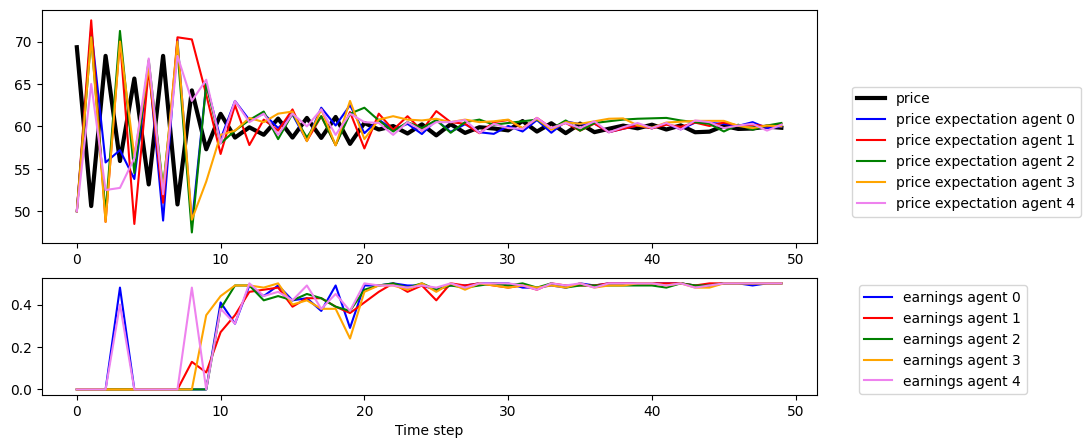

In [12]:
fig, axes = plt.subplots(nrows=2, ncols=1, figsize=(10, 5), gridspec_kw={'height_ratios': [2, 1]})
colors = ["blue","red","green","orange","violet","cyan","gold"]

axes[0].plot(p_array_on,label="price",color="black",linewidth = 3)
for i in range(n_agents):
    axes[0].plot(pe_agents_time_on[i,:],label="price expectation agent "+str(i),color=colors[i])
    axes[1].plot(rewards_agents_time_on[i,:],label="earnings agent "+str(i),color=colors[i])

#axes[0].set_ylim(0,100)
axes[0].legend(bbox_to_anchor=(1.35, 0.7))
axes[1].legend(bbox_to_anchor=(1.28, 1))

axes[1].set_xlabel("Time step")
# axes[0].set_xticks(range(n_steps))
# axes[1].set_xticks(range(n_steps))

In [6]:
feedback='neg'
for i in range(1, 11):
    expmnt_num = check_existing_file(path_exp, i, feedback, instruction_type, temperature, memory, n_steps, n_agents, gpt_model)
    p_array_op, pe_agents_time_op, rewards_agents_time_op, messages_list_op  = mod.run_experiment(seed,\
                expmnt_num, noise_mean, noise_sd, temperature, memory=memory, gpt_model=gpt_model, n_steps=n_steps, n_agents=n_agents,
                feedback=feedback, instruction_type=instruction_type, prints_on=True,\
                save_res_bool=True, path_exp=path_exp)

Checking files in absolute path: c:\Users\Sidney\OneDrive\文件\FYP\FYP\gpt_agents-master\results\experiments
Looking for file: c:\Users\Sidney\OneDrive\文件\FYP\FYP\gpt_agents-master\results\experiments\expmnt_results_neg_original_30-50w_num_1_temp_1_memory_3_ntime_50_nagents_5_model_gpt-3-5-turbo-0125.csv
File expmnt_results_neg_original_30-50w_num_1_temp_1_memory_3_ntime_50_nagents_5_model_gpt-3-5-turbo-0125.csv does not exist. Safe to proceed with experiment number 1.
Experiment Fingerprints: 5b556bb5e1ab2ebe3947c9e88cb1175d
 
 Time: 0, agent: 0 

{'role': 'user', 'content': 'This is the first time step, give an initial price prediction'}
{'role': 'assistant', 'content': '{\n  "reasoning": "Based on historical data and market trends, I predict the initial market price to be at the mid-range of 50 euros.",\n  "predictedValue": 50.00\n}'}
 
 Time: 0, agent: 1 

{'role': 'user', 'content': 'This is the first time step, give an initial price prediction'}
{'role': 'assistant', 'content': '{\